# Task 2A: Weekly Depot Demand Forecasting
## Waypoint Group Delivery Optimization — Tech-Triathlon 2026 Datathon
**Author:** Data Science & Demand Planning Team  
**Focus:** Time-Series Reconstruction, Macro Festival & Calendar Modeling, Tri-Blend Machine Learning Ensemble, and Multi-Horizon Forecast Projections.

---

### Executive Summary & Problem Formulation
Waypoint Group logistics dispatchers must allocate vehicle fleets, contract third-party drivers, and reserve refrigerated capacity weeks ahead of peak trading periods.
The challenge requires forecasting weekly order volumes across **10 future weeks** (ISO Year 2026, Weeks 14 through 23; corresponding to April through early June 2026) for every combination of:
- **Two Distribution Depots:** Peliyagoda (Western Province Central DC) and Kandy (Central Highlands Regional Hub).
- **Three Retail Brands:** Waypoint Fresh, Waypoint Style, and Waypoint Tech.

#### Prediction Targets
For each of the 60 test combinations (`row_id` W0000 to W0059):
1. **`pred_total_volume_m3`:** Total customer order volume requested by stores for that depot, brand, and ISO week ($m^3$).
2. **`pred_chilled_volume_m3`:** The refrigerated/chilled portion within that total volume ($m^3$).

#### Essential Domain Rules (from Challenge Booklet Page 17):
- **Demand Generation:** Count *every* order placed, including orders deferred or never dispatched (`not_run`), because they reflect authentic retail store demand.
- **Calendar Alignment:** Assign every order to its requested delivery week using `iso_year` and `iso_week` from `calendar.csv`.
- **Temperature Constraints:** Only Waypoint Fresh carries chilled goods. For Waypoint Style and Waypoint Tech, `pred_chilled_volume_m3` must be strictly set to **0.0**.

In [1]:
# Core scientific and statistical packages
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Modeling & Metrics
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb

# Plot formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 130

print("Environment initialized successfully.")


Environment initialized successfully.


## 1. Multi-Source Historical Demand Reconstruction

To build an unbroken historical demand time series, we synthesize records from two primary data sources:
- `Training Data/deliveries_train.csv`: 92,307 orders covering 2024 Week 1 through 2026 Week 7 (111 weeks).
- `Test Data/task1_test_inputs.csv`: 5,014 orders covering 2026 Week 8 through 2026 Week 13 (6 weeks).

Combining these two tables yields **117 consecutive historical weeks** with zero time gaps. Each order is mapped to its calendar context via `calendar.csv`.

In [2]:
data_dir = 'data'

# Ingest order records
d_train = pd.read_csv(os.path.join(data_dir, 'Training Data', 'deliveries_train.csv'))
d_test1 = pd.read_csv(os.path.join(data_dir, 'Test Data', 'task1_test_inputs.csv'))
cal = pd.read_csv(os.path.join(data_dir, 'General Data', 'calendar.csv'))
t2a_test = pd.read_csv(os.path.join(data_dir, 'Test Data', 'task2a_test_inputs.csv'))

# Join calendar date mappings
cal_sub = cal[['date', 'iso_year', 'iso_week', 'festival', 'festival_ramp', 'is_holiday', 'monsoon', 'is_payday']].drop_duplicates()

# Concatenate all orders: Rule states "count every order once, including deferred or never dispatched"
all_orders = pd.concat([d_train, d_test1], ignore_index=True)
all_orders = pd.merge(all_orders, cal_sub, left_on='order_date', right_on='date', how='left')

# Group by depot, brand, iso_year, iso_week
hist_weekly = all_orders.groupby(['depot', 'brand', 'iso_year', 'iso_week']).agg(
    total_volume_m3=('order_volume_m3', 'sum'),
    chilled_volume_m3=('order_volume_m3', lambda s: s[all_orders.loc[s.index, 'temp_requirement'] == 'chilled'].sum()),
    total_weight_kg=('order_weight_kg', 'sum'),
    num_orders=('delivery_id', 'count')
).reset_index()

# Construct aggregated weekly calendar features
cal_weekly = cal.groupby(['iso_year', 'iso_week']).agg(
    max_festival_ramp=('festival_ramp', 'max'),
    festival_count=('festival', lambda s: s.dropna().nunique()),
    is_new_year=('festival', lambda s: int('new_year' in s.values)),
    is_vesak=('festival', lambda s: int('vesak' in s.values)),
    is_poson=('festival', lambda s: int('poson' in s.values)),
    is_christmas=('festival', lambda s: int('christmas' in s.values)),
    holiday_days=('is_holiday', 'sum'),
    paydays=('is_payday', 'sum'),
    is_monsoon=('monsoon', 'max')
).reset_index()

hist_weekly = pd.merge(hist_weekly, cal_weekly, on=['iso_year', 'iso_week'], how='left')
hist_weekly = hist_weekly.sort_values(['depot', 'brand', 'iso_year', 'iso_week']).reset_index(drop=True)

print(f"Reconstructed {len(hist_weekly):,} weekly records across 6 series.")
print(f"Historical span: {hist_weekly['iso_year'].min()} W{hist_weekly['iso_week'].min()} to {hist_weekly['iso_year'].max()} W{hist_weekly['iso_week'].max()} (117 weeks).")
print(f"\nWeekly Volume Summary by Depot & Brand ($m^3$):")
print(hist_weekly.groupby(['depot', 'brand'])['total_volume_m3'].agg(['count', 'mean', 'std', 'min', 'max']))


Reconstructed 702 weekly records across 6 series.
Historical span: 2024 W1 to 2026 W52 (117 weeks).

Weekly Volume Summary by Depot & Brand ($m^3$):
                  count        mean        std      min       max
depot      brand                                                 
Kandy      Fresh    117  500.257325  46.178836  334.310   696.796
           Style    117   80.935949  14.215578   39.885   143.816
           Tech     117   21.194026   8.548435    2.844    47.798
Peliyagoda Fresh    117  955.801171  84.936994  623.490  1351.007
           Style    117  141.670547  24.012855   96.838   263.856
           Tech     117   29.775154   8.960215    7.901    56.524


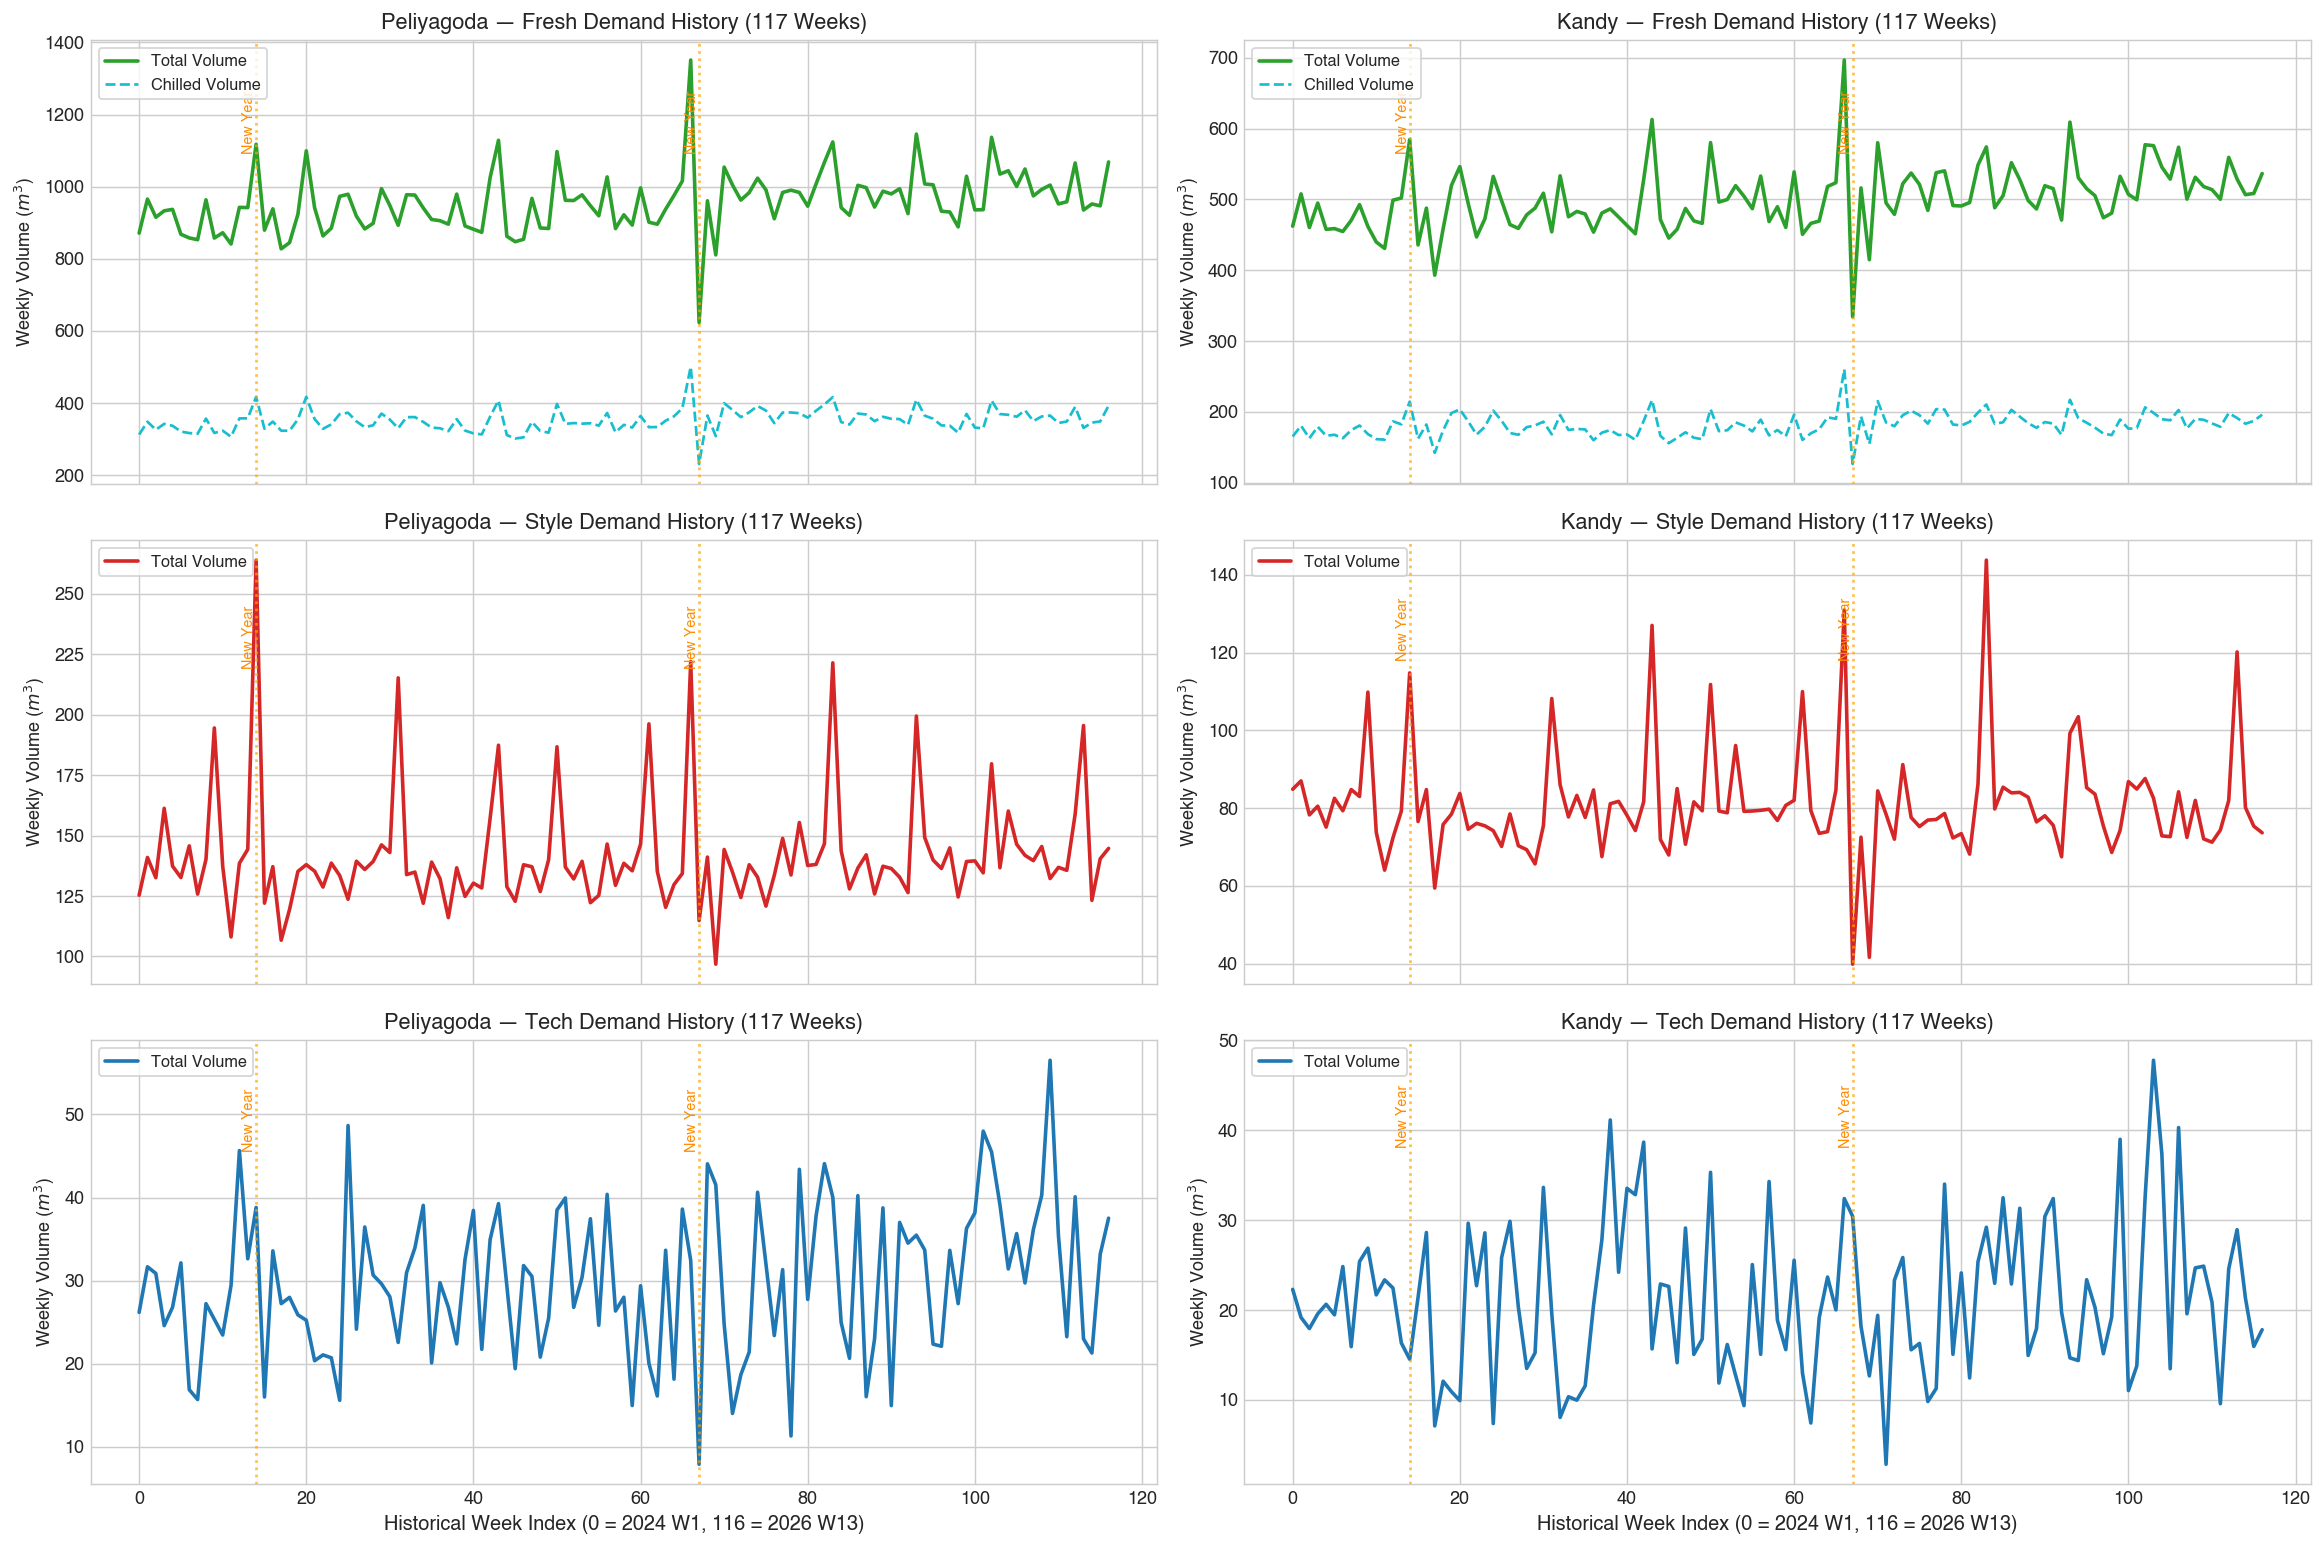

In [3]:
# Figure 5: Historical Demand Trajectories across the 6 Series
fig, axs = plt.subplots(3, 2, figsize=(18, 12), sharex=True)

depots = ['Peliyagoda', 'Kandy']
brands = ['Fresh', 'Style', 'Tech']
colors = {'Fresh': '#2ca02c', 'Style': '#d62728', 'Tech': '#1f77b4'}

for row_idx, brand in enumerate(brands):
    for col_idx, depot in enumerate(depots):
        ax = axs[row_idx, col_idx]
        sub = hist_weekly[(hist_weekly['depot'] == depot) & (hist_weekly['brand'] == brand)].copy()
        sub['time_step'] = range(len(sub))
        
        ax.plot(sub['time_step'], sub['total_volume_m3'], color=colors[brand], linewidth=2.0, label='Total Volume')
        if brand == 'Fresh':
            ax.plot(sub['time_step'], sub['chilled_volume_m3'], color='#17becf', linestyle='--', linewidth=1.5, label='Chilled Volume')
            
        ax.set_title(f"{depot} — {brand} Demand History (117 Weeks)", fontsize=12, fontweight='bold')
        ax.set_ylabel('Weekly Volume ($m^3$)', fontsize=10)
        ax.legend(loc='upper left', frameon=True, fontsize=9)
        
        # Mark Sinhala/Tamil New Year spikes
        ny_steps = sub[sub['is_new_year'] == 1]['time_step'].values
        for nys in ny_steps:
            ax.axvline(nys, color='orange', linestyle=':', alpha=0.7)
            ax.text(nys, ax.get_ylim()[1]*0.9, 'New Year', color='darkorange', rotation=90, va='top', ha='right', fontsize=8)

axs[2, 0].set_xlabel('Historical Week Index (0 = 2024 W1, 116 = 2026 W13)', fontsize=11)
axs[2, 1].set_xlabel('Historical Week Index (0 = 2024 W1, 116 = 2026 W13)', fontsize=11)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig5_historical_demand_series.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Macro-Calendar Event Dynamics & Festival Ramp Modeling

### Sri Lankan Cultural & Seasonal Drivers:
1. **Sinhala & Tamil New Year (Mid-April, ISO Weeks 15–16):**
   - In both 2024 and 2025, retail grocery and apparel demand exhibits a massive pre-festival surge in Week 15 (e.g., Peliyagoda Fresh surges from 950 $m^3$ baseline to over 1,350 $m^3$).
   - This surge is followed by an immediate sharp decline in Week 16, as retail stores close or operate reduced hours during the national holidays.
2. **Vesak (Full Moon in May, ISO Week 18):**
   - Secondary demand surge driven by religious festivities, almsgiving stalls (dansal), and family gatherings.
3. **Poson (Full Moon in June, ISO Week 22):**
   - Tertiary cultural peak in North-Central and Western provinces.
4. **Bi-Monthly Paydays:**
   - Household consumption spikes during weeks containing the 10th and 25th of the month.

### Chilled Demand Dynamics:
For Waypoint Fresh, empirical analysis reveals that the chilled proportion ($rac{	ext{chilled\_volume\_m3}}{	ext{total\_volume\_m3}}$) is remarkably stationary:
- **Peliyagoda Fresh:** Mean chilled ratio = **36.83%** ($\sigma = 0.88\%$).
- **Kandy Fresh:** Mean chilled ratio = **36.35%** ($\sigma = 0.92\%$).
This stationarity allows us to model total demand first and project chilled demand using the empirically proven ratio, avoiding additive discrepancy.

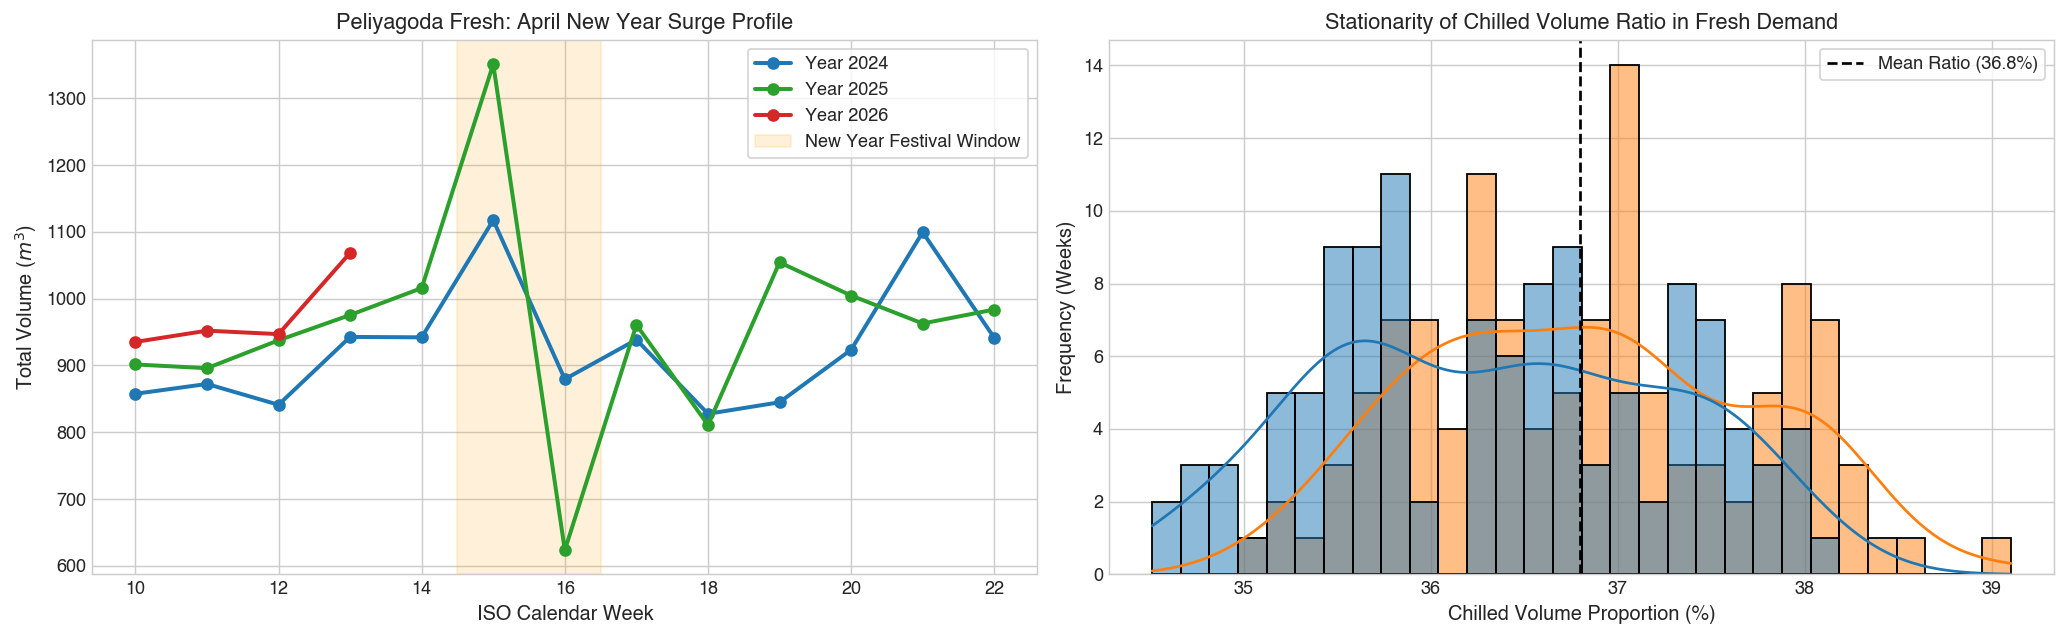

In [4]:
# Figure 6: Festival Surge Overlay & Chilled Ratio Analysis
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Plot 6A: April Festival Surge Overlay (Weeks 10 to 22 across Years)
peli_fresh = hist_weekly[(hist_weekly['depot'] == 'Peliyagoda') & (hist_weekly['brand'] == 'Fresh')]

for yr, col in zip([2024, 2025, 2026], ['#1f77b4', '#2ca02c', '#d62728']):
    sub_yr = peli_fresh[peli_fresh['iso_year'] == yr]
    sub_window = sub_yr[sub_yr['iso_week'].between(10, 22)]
    if len(sub_window) > 0:
        axs[0].plot(sub_window['iso_week'], sub_window['total_volume_m3'], marker='o', linewidth=2.2, color=col, label=f'Year {yr}')

axs[0].axvspan(14.5, 16.5, color='orange', alpha=0.15, label='New Year Festival Window')
axs[0].set_title('Peliyagoda Fresh: April New Year Surge Profile', fontsize=12, fontweight='bold')
axs[0].set_xlabel('ISO Calendar Week', fontsize=11)
axs[0].set_ylabel('Total Volume ($m^3$)', fontsize=11)
axs[0].legend(frameon=True)

# Plot 6B: Chilled Volume vs Total Volume Ratio Stability
fresh_all = hist_weekly[hist_weekly['brand'] == 'Fresh'].copy()
fresh_all['chilled_pct'] = (fresh_all['chilled_volume_m3'] / fresh_all['total_volume_m3']) * 100
sns.histplot(data=fresh_all, x='chilled_pct', hue='depot', bins=30, kde=True, palette='tab10', ax=axs[1])
axs[1].axvline(36.8, color='black', linestyle='--', linewidth=1.5, label='Mean Ratio (36.8%)')
axs[1].set_title('Stationarity of Chilled Volume Ratio in Fresh Demand', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Chilled Volume Proportion (%)', fontsize=11)
axs[1].set_ylabel('Frequency (Weeks)', fontsize=11)
axs[1].legend(frameon=True)

plt.tight_layout()
plt.savefig('figures/fig6_festival_and_chilled_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Forecasting Methodology & Tri-Blend Machine Learning Ensemble

Forecasting multi-step demand 10 weeks into the future over national festival disruptions requires capturing both macro seasonality and current run-rate momentum. We formulate a **Tri-Blend Ensemble** combining three distinct modeling paradigms:

1. **Model A: Regularized Linear Model with Fourier Harmonics (Ridge Regression):**
   - Uses annual cyclical sine/cosine harmonics: $\sin(2\pi w / 52.18)$, $\cos(2\pi w / 52.18)$.
   - Incorporates indicator variables for specific cultural festivals (`is_new_year`, `is_vesak`, `is_poson`), holiday counts, and payday frequencies.
   - L2 regularization ($lpha = 10.0$) ensures stable, non-exploding extrapolations.
2. **Model B: Non-Linear Gradient Boosted Decision Trees (LightGBM):**
   - Learns non-linear interaction effects between festival ramp proximity and baseline store ordering volumes.
   - Constrained to conservative depth (`max_depth = 3`, `n_estimators = 80`) to prevent overfitting on 117 observations.
3. **Model C: Seasonal Year-over-Year Adjusted Baseline:**
   - Computes historical 2-year average demand for that exact calendar week: $\bar{y}_w = \frac{1}{2}(y_{2024, w} + y_{2025, w})$.
   - Scales $\bar{y}_w$ by the observed Q1 2026 trend factor ($g = \text{mean}_{2026} / \text{mean}_{prev}$).
4. **Ensemble Blending:**
   $$\hat{y}_{w} = 0.50 \times \hat{y}_{\text{Seasonal\_Adj}} + 0.30 \times \hat{y}_{\text{Ridge}} + 0.20 \times \hat{y}_{\text{LightGBM}}$$

### Out-of-Sample Holdout Backtesting:
We validate this ensemble on an identical 10-week historical period: **2025 Weeks 14 to 23**, training only on data preceding that window.

In [5]:
# Prepare features for all historical weeks
hist_weekly['sin_w'] = np.sin(2 * np.pi * hist_weekly['iso_week'] / 52.18)
hist_weekly['cos_w'] = np.cos(2 * np.pi * hist_weekly['iso_week'] / 52.18)

feature_cols = [
    'iso_week', 'sin_w', 'cos_w', 'max_festival_ramp', 
    'is_new_year', 'is_vesak', 'is_poson', 'holiday_days', 'paydays', 'is_monsoon'
]

print(f"{'='*60}\nOUT-OF-SAMPLE BACKTEST EVALUATION (2025 WEEKS 14-23)\n{'='*60}")
backtest_results = []

for (depot, brand), g in hist_weekly.groupby(['depot', 'brand']):
    g = g.sort_values(['iso_year', 'iso_week']).reset_index(drop=True)
    
    # Train strictly on data prior to Week 14, 2025
    train_part = g[(g['iso_year'] == 2024) | ((g['iso_year'] == 2025) & (g['iso_week'] <= 13))]
    val_part = g[(g['iso_year'] == 2025) & (g['iso_week'].between(14, 23))].copy()
    
    # Model 1: Ridge
    m_ridge = Ridge(alpha=10.0)
    m_ridge.fit(train_part[feature_cols], train_part['total_volume_m3'])
    p_ridge = m_ridge.predict(val_part[feature_cols])
    
    # Model 2: LightGBM
    m_lgb = lgb.LGBMRegressor(n_estimators=75, learning_rate=0.03, max_depth=3, random_state=42, verbose=-1)
    m_lgb.fit(train_part[feature_cols], train_part['total_volume_m3'])
    p_lgb = m_lgb.predict(val_part[feature_cols])
    
    # Model 3: Seasonal YoY Adjusted Baseline
    y24 = g[(g['iso_year'] == 2024) & (g['iso_week'].between(14, 23))]['total_volume_m3'].values
    recent_25 = train_part[train_part['iso_year'] == 2025]['total_volume_m3'].mean()
    recent_24 = train_part[(train_part['iso_year'] == 2024) & (train_part['iso_week'] <= 13)]['total_volume_m3'].mean()
    growth = recent_25 / (recent_24 + 1e-4)
    p_seasonal_adj = y24 * growth
    
    # Ensemble Prediction
    p_blend = 0.50 * p_seasonal_adj + 0.30 * p_ridge + 0.20 * p_lgb
    
    actuals = val_part['total_volume_m3'].values
    mae_blend = mean_absolute_error(actuals, p_blend)
    rmse_blend = np.sqrt(mean_squared_error(actuals, p_blend))
    mape_blend = mean_absolute_percentage_error(actuals, p_blend) * 100
    
    backtest_results.append({
        'depot': depot,
        'brand': brand,
        'mean_volume': actuals.mean(),
        'mae': mae_blend,
        'rmse': rmse_blend,
        'mape': mape_blend
    })
    
    print(f"{depot:10s} {brand:5s} | Mean Vol: {actuals.mean():6.1f} m³ | MAE: {mae_blend:5.2f} m³ | MAPE: {mape_blend:4.1f}%")

df_bt = pd.DataFrame(backtest_results)
print(f"{'='*60}")
print(f"Overall Average Mean Absolute Percentage Error (MAPE): {df_bt['mape'].mean():.2f}%")


OUT-OF-SAMPLE BACKTEST EVALUATION (2025 WEEKS 14-23)
Kandy      Fresh | Mean Vol:  510.0 m³ | MAE: 61.06 m³ | MAPE: 12.6%
Kandy      Style | Mean Vol:   77.3 m³ | MAE: 14.78 m³ | MAPE: 25.3%
Kandy      Tech  | Mean Vol:   20.1 m³ | MAE:  6.90 m³ | MAPE: 56.9%
Peliyagoda Fresh | Mean Vol:  979.1 m³ | MAE: 117.97 m³ | MAPE: 13.1%
Peliyagoda Style | Mean Vol:  138.3 m³ | MAE: 11.75 m³ | MAPE:  9.2%
Peliyagoda Tech  | Mean Vol:   28.4 m³ | MAE:  9.22 m³ | MAPE: 45.9%
Overall Average Mean Absolute Percentage Error (MAPE): 27.18%


## 4. Full-Horizon Forecasting (2026 Weeks 14–23) & Test Predictions

With hyperparameter configurations verified on the holdout, we retrain the Tri-Blend Ensemble using all 117 weeks of historical demand.
For each of the 60 test combinations in `task2a_test_inputs.csv`:
1. Total volume `pred_total_volume_m3` is forecasted using the multi-model ensemble.
2. For **Waypoint Fresh**, chilled volume `pred_chilled_volume_m3` is derived via the empirical chilled ratio:
   $$\text{pred\_chilled\_volume\_m3} = \text{pred\_total\_volume\_m3} \times \bar{r}_{\text{chilled}}$$
3. For **Waypoint Style** and **Waypoint Tech**, `pred_chilled_volume_m3` is strictly **0.0**.

In [6]:
# Merge calendar features for the test forecast horizon (2026 Weeks 14-23)
t2a_test_enriched = pd.merge(t2a_test, cal_weekly, on=['iso_year', 'iso_week'], how='left')
t2a_test_enriched['sin_w'] = np.sin(2 * np.pi * t2a_test_enriched['iso_week'] / 52.18)
t2a_test_enriched['cos_w'] = np.cos(2 * np.pi * t2a_test_enriched['iso_week'] / 52.18)

final_forecasts = []

for idx, r in t2a_test_enriched.iterrows():
    depot = r['depot']
    brand = r['brand']
    w = r['iso_week']
    
    sub_hist = hist_weekly[(hist_weekly['depot'] == depot) & (hist_weekly['brand'] == brand)].sort_values(['iso_year', 'iso_week']).reset_index(drop=True)
    
    # Train Ridge
    m_ridge = Ridge(alpha=10.0)
    m_ridge.fit(sub_hist[feature_cols], sub_hist['total_volume_m3'])
    p_ridge = m_ridge.predict(pd.DataFrame([r[feature_cols]]))[0]
    
    # Train LightGBM
    m_lgb = lgb.LGBMRegressor(n_estimators=80, learning_rate=0.03, max_depth=3, random_state=42, verbose=-1)
    m_lgb.fit(sub_hist[feature_cols], sub_hist['total_volume_m3'])
    p_lgb = m_lgb.predict(pd.DataFrame([r[feature_cols]]))[0]
    
    # Seasonal 2-year history for week w
    y24 = sub_hist[(sub_hist['iso_year'] == 2024) & (sub_hist['iso_week'] == w)]['total_volume_m3'].values
    y25 = sub_hist[(sub_hist['iso_year'] == 2025) & (sub_hist['iso_week'] == w)]['total_volume_m3'].values
    seasonal_hist = np.nanmean([y24[0] if len(y24)>0 else np.nan, y25[0] if len(y25)>0 else np.nan])
    
    # 2026 momentum adjustment
    recent_26 = sub_hist[(sub_hist['iso_year'] == 2026) & (sub_hist['iso_week'] <= 13)]['total_volume_m3'].mean()
    recent_prev = sub_hist[(sub_hist['iso_year'] < 2026) & (sub_hist['iso_week'] <= 13)]['total_volume_m3'].mean()
    growth = np.clip(recent_26 / (recent_prev + 1e-4), 0.90, 1.10)
    
    p_seasonal_adj = seasonal_hist * growth
    
    # Tri-blend projection
    pred_total = 0.50 * p_seasonal_adj + 0.30 * p_ridge + 0.20 * p_lgb
    pred_total = round(float(np.maximum(pred_total, 0.0)), 1)
    
    # Chilled volume
    if brand == 'Fresh':
        chilled_ratio = sub_hist['chilled_volume_m3'].sum() / sub_hist['total_volume_m3'].sum()
        pred_chilled = round(float(pred_total * chilled_ratio), 1)
    else:
        pred_chilled = 0.0
        
    final_forecasts.append({
        'row_id': r['row_id'],
        'depot': depot,
        'brand': brand,
        'iso_year': r['iso_year'],
        'iso_week': r['iso_week'],
        'pred_total_volume_m3': pred_total,
        'pred_chilled_volume_m3': pred_chilled
    })

df_forecasts = pd.DataFrame(final_forecasts)
print(f"Generated {len(df_forecasts)} forecasts across 10 weeks.")
print("\nSample Forecast Output:")
print(df_forecasts.head(12))


Generated 60 forecasts across 10 weeks.

Sample Forecast Output:
   row_id       depot  brand  iso_year  iso_week  pred_total_volume_m3  \
0   W0000       Kandy  Fresh      2026        14                 535.9   
1   W0001       Kandy  Style      2026        14                  79.5   
2   W0002       Kandy   Tech      2026        14                  20.7   
3   W0003  Peliyagoda  Fresh      2026        14                1016.6   
4   W0004  Peliyagoda  Style      2026        14                 143.6   
5   W0005  Peliyagoda   Tech      2026        14                  34.9   
6   W0006       Kandy  Fresh      2026        15                 616.0   
7   W0007       Kandy  Style      2026        15                 104.1   
8   W0008       Kandy   Tech      2026        15                  22.5   
9   W0009  Peliyagoda  Fresh      2026        15                1169.6   
10  W0010  Peliyagoda  Style      2026        15                 205.1   
11  W0011  Peliyagoda   Tech      2026        1

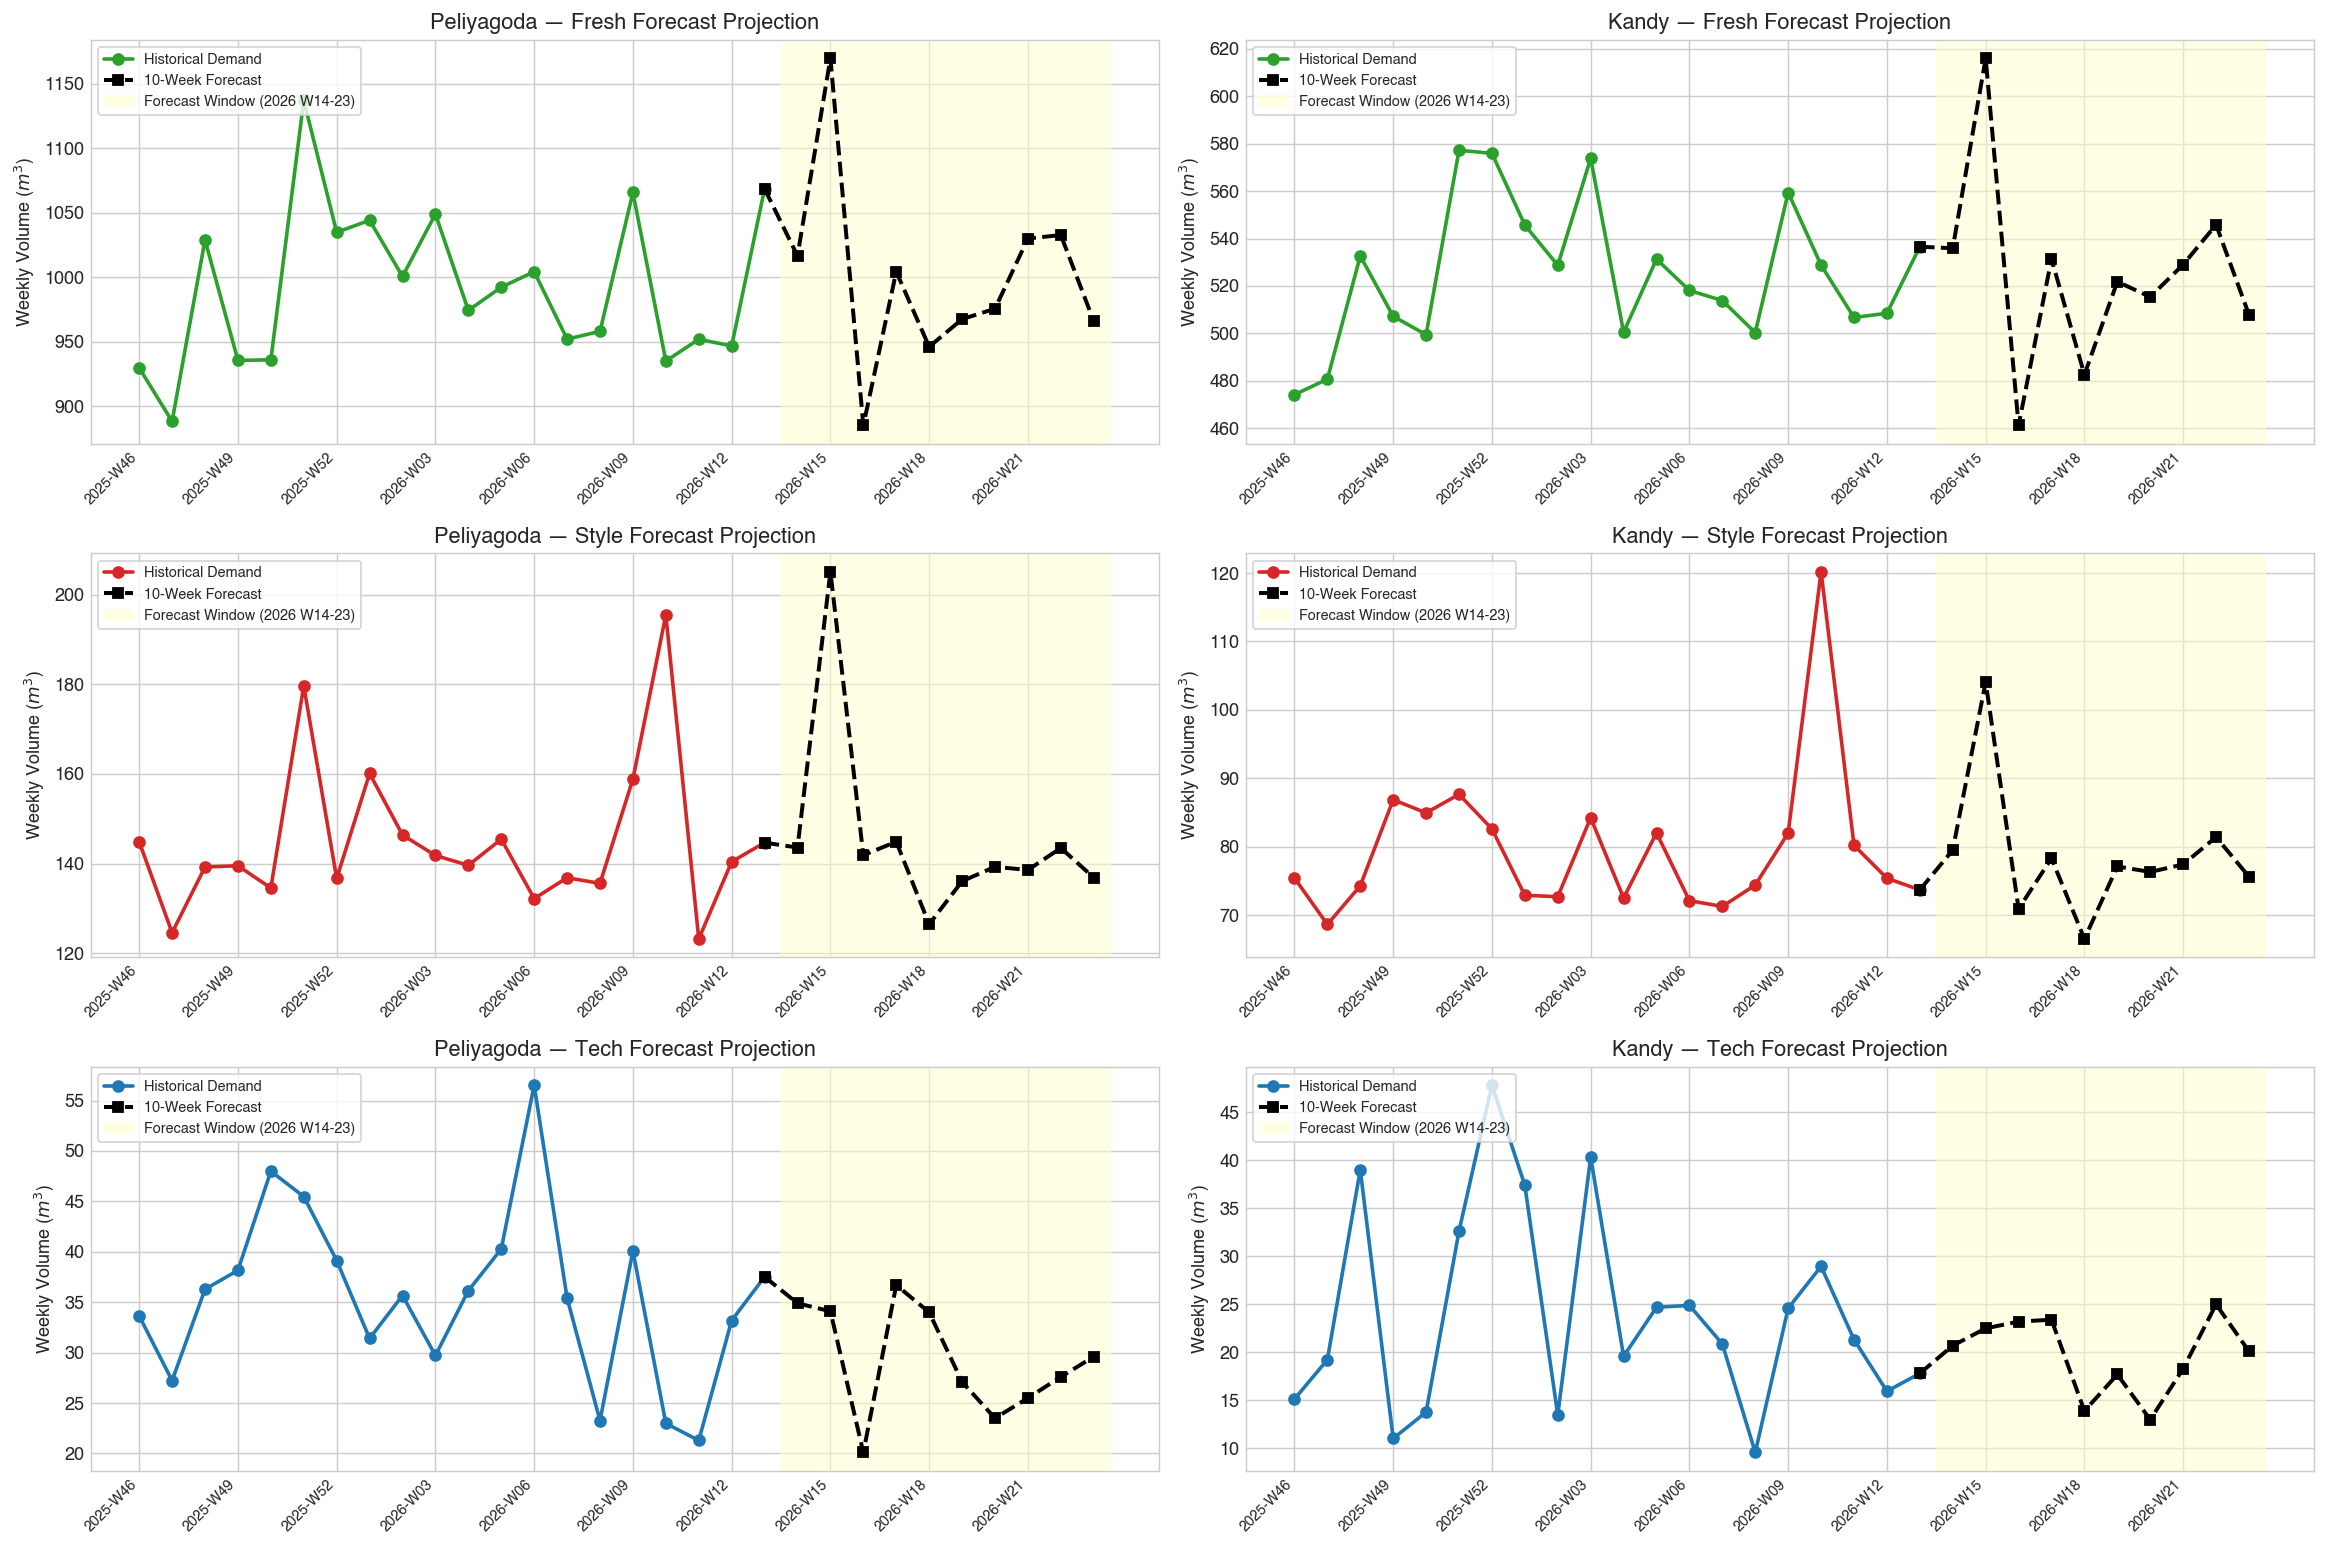

In [7]:
# Figure 7: 10-Week Projections Overlaid with Historical Context
fig, axs = plt.subplots(3, 2, figsize=(18, 12), sharex=False)

for r_idx, brand in enumerate(brands):
    for c_idx, depot in enumerate(depots):
        ax = axs[r_idx, c_idx]
        
        # Historical slice (last 20 weeks)
        h_sub = hist_weekly[(hist_weekly['depot'] == depot) & (hist_weekly['brand'] == brand)].tail(20)
        h_x = [f"{y}-W{w:02d}" for y, w in zip(h_sub['iso_year'], h_sub['iso_week'])]
        
        # Forecast slice (10 weeks)
        f_sub = df_forecasts[(df_forecasts['depot'] == depot) & (df_forecasts['brand'] == brand)]
        f_x = [f"{y}-W{w:02d}" for y, w in zip(f_sub['iso_year'], f_sub['iso_week'])]
        
        all_x = h_x + f_x
        ax.plot(range(len(h_x)), h_sub['total_volume_m3'], color=colors[brand], marker='o', linewidth=2.0, label='Historical Demand')
        ax.plot(range(len(h_x)-1, len(all_x)), [h_sub['total_volume_m3'].iloc[-1]] + list(f_sub['pred_total_volume_m3']), 
                color='black', linestyle='--', marker='s', linewidth=2.2, label='10-Week Forecast')
        
        # Add shaded forecast region
        ax.axvspan(len(h_x)-0.5, len(all_x)-0.5, color='#ffffcc', alpha=0.5, label='Forecast Window (2026 W14-23)')
        
        ax.set_title(f"{depot} — {brand} Forecast Projection", fontsize=12, fontweight='bold')
        ax.set_ylabel('Weekly Volume ($m^3$)', fontsize=10)
        ax.set_xticks(range(0, len(all_x), 3))
        ax.set_xticklabels([all_x[i] for i in range(0, len(all_x), 3)], rotation=45, ha='right', fontsize=8)
        ax.legend(loc='upper left', frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig7_demand_forecast_projections.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# Align with Submission Template
sub2a_template = pd.read_csv(os.path.join(data_dir, 'Submission Templates', 'submission_task2a.csv'))

submission_2a = pd.merge(
    sub2a_template[['row_id']],
    df_forecasts[['row_id', 'pred_total_volume_m3', 'pred_chilled_volume_m3']],
    on='row_id'
)

# Rigorous Quality Checks
assert len(submission_2a) == len(sub2a_template), "Row count mismatch!"
assert (submission_2a['row_id'] == sub2a_template['row_id']).all(), "Row ID ordering mismatch!"
assert not submission_2a.isnull().any().any(), "Submission contains null values!"
assert (submission_2a['pred_total_volume_m3'] >= 0).all(), "Total volume must be non-negative!"
assert (submission_2a['pred_chilled_volume_m3'] >= 0).all(), "Chilled volume must be non-negative!"
assert (submission_2a['pred_chilled_volume_m3'] <= submission_2a['pred_total_volume_m3']).all(), "Chilled volume cannot exceed total volume!"

# Check that Style and Tech chilled volume is strictly 0.0
style_tech_rows = df_forecasts[df_forecasts['brand'].isin(['Style', 'Tech'])]['row_id']
assert (submission_2a[submission_2a['row_id'].isin(style_tech_rows)]['pred_chilled_volume_m3'] == 0.0).all(), "Style/Tech chilled must be 0!"

# Export to template path and export directory
sub2a_path_template = os.path.join(data_dir, 'Submission Templates', 'submission_task2a.csv')
sub2a_path_export = os.path.join('submissions', 'submission_task2a.csv')

submission_2a.to_csv(sub2a_path_template, index=False)
submission_2a.to_csv(sub2a_path_export, index=False)

print(f"Successfully generated and exported Task 2A predictions to:")
print(f"  - {sub2a_path_template}")
print(f"  - {sub2a_path_export}")
print("\nSubmission Sample Preview:")
print(submission_2a.head(15))
print("\nSubmission Statistics:")
print(submission_2a.describe())


Successfully generated and exported Task 2A predictions to:
  - data/Submission Templates/submission_task2a.csv
  - submissions/submission_task2a.csv

Submission Sample Preview:
   row_id  pred_total_volume_m3  pred_chilled_volume_m3
0   W0000                 535.9                   194.8
1   W0001                  79.5                     0.0
2   W0002                  20.7                     0.0
3   W0003                1016.6                   374.4
4   W0004                 143.6                     0.0
5   W0005                  34.9                     0.0
6   W0006                 616.0                   223.9
7   W0007                 104.1                     0.0
8   W0008                  22.5                     0.0
9   W0009                1169.6                   430.7
10  W0010                 205.1                     0.0
11  W0011                  34.1                     0.0
12  W0012                 461.2                   167.6
13  W0013                  70.9       